# **Customer Support Ticket Categorisation**

## **Project Overview**
This project aims to build an end-to-end NLP pipeline to automatically categorize customer support tickets into four main categories: Technical, Billing, Account, and Other. By leveraging Machine Learning and Large Language Models (LLMs), the system identifies the nature of a problem from the ticket's subject and body to streamline support workflows.


## *Dataset :*

[https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset](https://)

## *Columns :*
- Ticket ID: A unique identifier for each ticket.

- Customer Name: The name of the customer who raised the ticket.

- Customer Email: The email address of the customer (Domain name - @example.com is intentional for user data privacy concern).

- Customer Age: The age of the customer.

- Customer Gender: The gender of the customer.

- Product Purchased: The tech product purchased by the customer.

- Date of Purchase: The date when the product was purchased.

- Ticket Type: The type of ticket (e.g., technical issue, billing inquiry, product inquiry).

- Ticket Subject: The subject/topic of the ticket.

- Ticket Description: The description of the customer's issue or inquiry.

- Ticket Status: The status of the ticket (e.g., open, closed, pending customer response).

- Resolution: The resolution or solution provided for closed tickets.

- Ticket Priority: The priority level assigned to the ticket (e.g., low, medium, high, critical).

- Ticket Channel: The channel through which the ticket was raised (e.g., email, phone, chat, social media).

- First Response Time: The time taken to provide the first response to the customer.

- Time to Resolution: The time taken to resolve the ticket.

- Customer Satisfaction Rating: The customer's satisfaction rating for closed tickets (on a scale of 1 to 5).

## *Loading Dataset*

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("suraj520/customer-support-ticket-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-support-ticket-dataset' dataset.
Path to dataset files: /kaggle/input/customer-support-ticket-dataset


In [2]:
path

'/kaggle/input/customer-support-ticket-dataset'

In [3]:
# Read the dataset

import pandas as pd
import os
data = pd.read_csv(os.path.join(path, 'customer_support_tickets.csv'))
data.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## *Visualization & Analysiss*

## **1. Data Understanding**

In [4]:
# Dataset shape (rows, columns)

data.shape

(8469, 17)

In [5]:
# Data Types

data.dtypes

,0
Ticket ID,int64
Customer Name,object
Customer Email,object
Customer Age,int64
Customer Gender,object
Product Purchased,object
Date of Purchase,object
Ticket Type,object
Ticket Subject,object
Ticket Description,object


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [7]:
# Missing Values Analysis

data.isnull().sum()

,0
Ticket ID,0
Customer Name,0
Customer Email,0
Customer Age,0
Customer Gender,0
Product Purchased,0
Date of Purchase,0
Ticket Type,0
Ticket Subject,0
Ticket Description,0


In [8]:
# Duplicate samples check

data.duplicated().sum()

np.int64(0)

In [9]:
# Basic statistics

data.describe()

,Ticket ID,Customer Age,Customer Satisfaction Rating
count,8469.000000,8469.000000,2769.000000
mean,4235.000000,44.026804,2.991333
std,2444.934048,15.296112,1.407016
min,1.000000,18.000000,1.000000
25%,2118.000000,31.000000,2.000000
50%,4235.000000,44.000000,3.000000
75%,6352.000000,57.000000,4.000000
max,8469.000000,70.000000,5.000000


In [10]:
data.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## **2. Target / Label Analysis**

In [11]:
target_col = ['Ticket Type']
data[target_col].value_counts()

,count
Ticket Type,
Refund request,1752
Technical issue,1747
Cancellation request,1695
Product inquiry,1641
Billing inquiry,1634


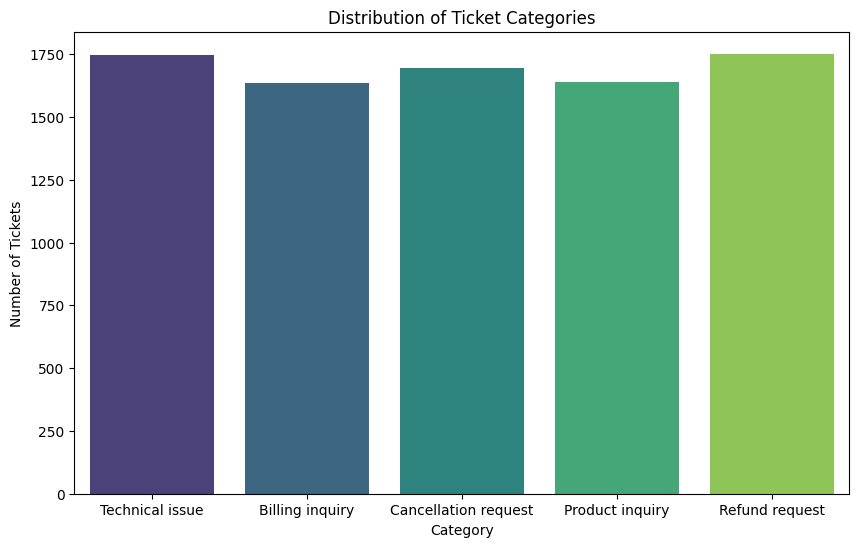

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

target_col = 'Ticket Type'
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x=target_col, hue=target_col, palette='viridis', legend=False)
plt.title('Distribution of Ticket Categories')
plt.xlabel('Category')
plt.ylabel('Number of Tickets')

plt.show()

In [13]:
# Check imbalance

(data[target_col].value_counts(normalize=True) * 100).round(2).astype(str) + '%'


,proportion
Ticket Type,
Refund request,20.69%
Technical issue,20.63%
Cancellation request,20.01%
Product inquiry,19.38%
Billing inquiry,19.29%


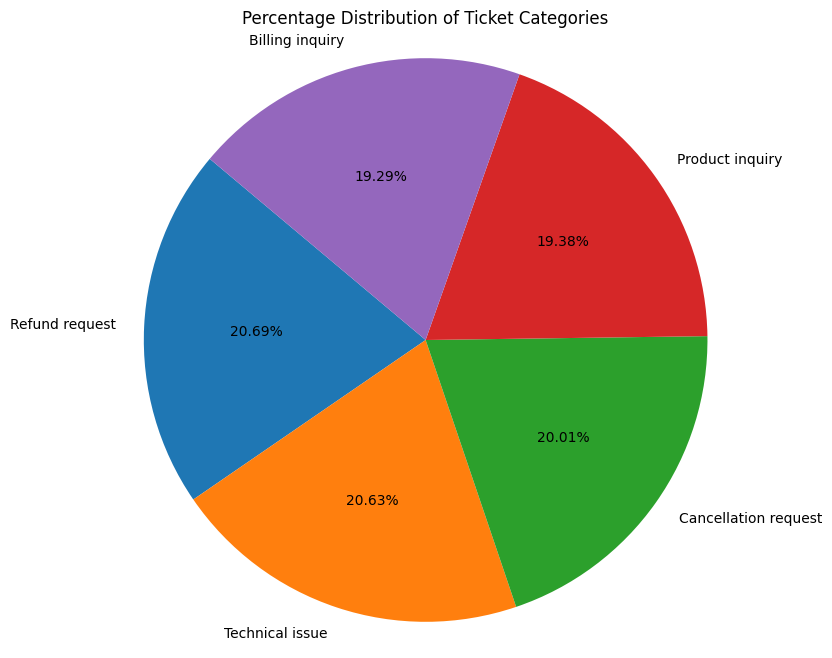

In [14]:
# Pie Chart

target_counts = data[target_col].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.2f%%',
        startangle=140)

plt.title('Percentage Distribution of Ticket Categories')
plt.axis('equal')
plt.show()

## **3. Feature Analysis**

### ***Numerical Features***

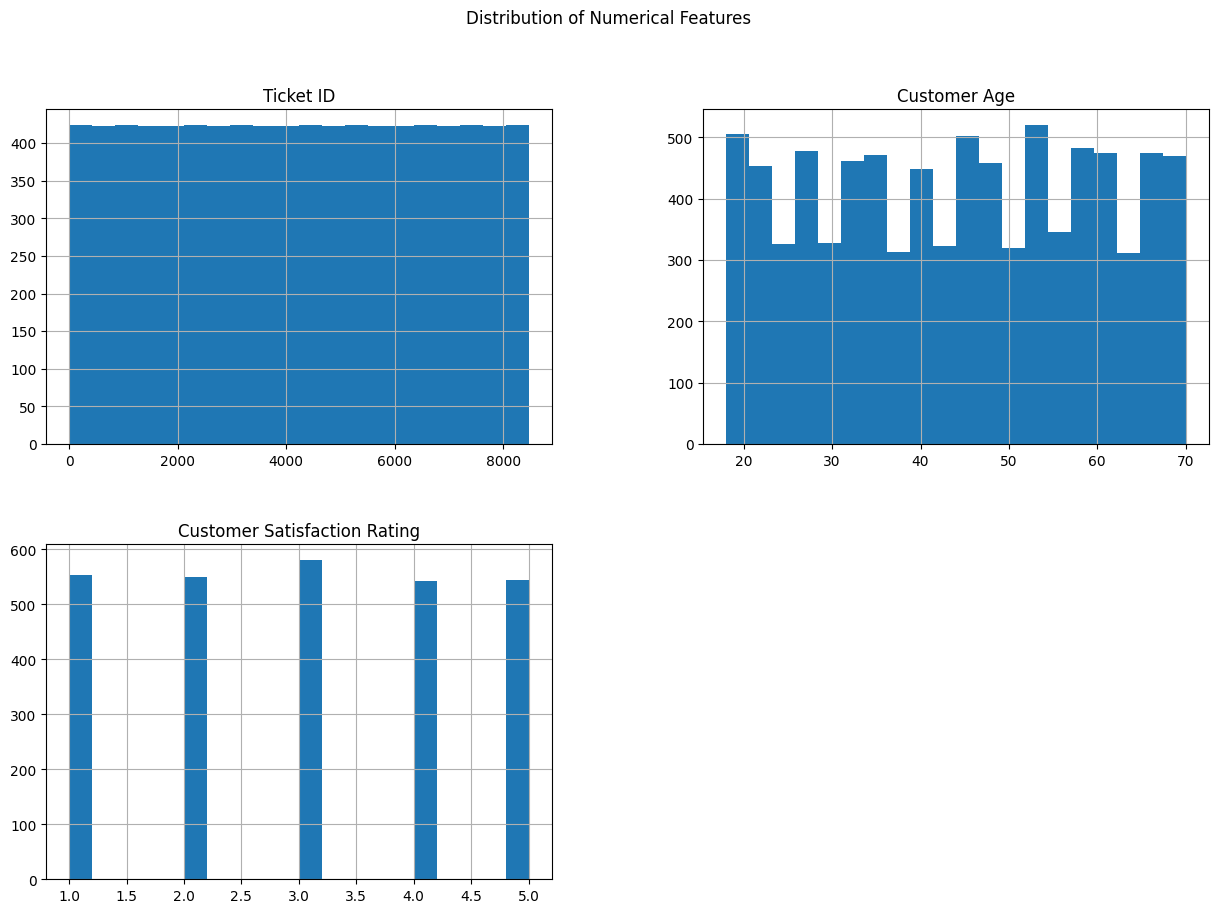

In [15]:
# Distribution plots (Histogram )

numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns

if len(numerical_cols) > 0:
    data[numerical_cols].hist(bins=20, figsize=(15, 10))
    plt.suptitle('Distribution of Numerical Features')
    plt.show()

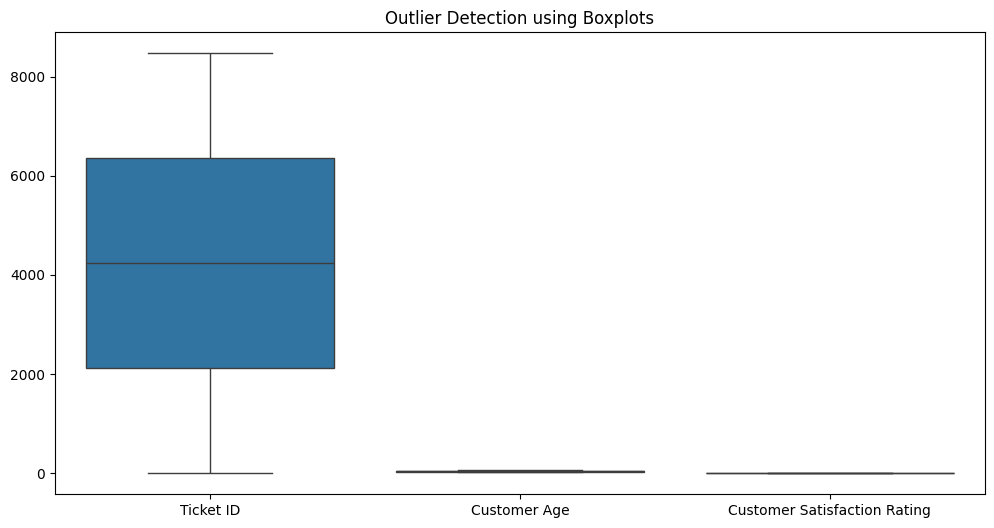

In [16]:
# Boxplots (outlier detection)

plt.figure(figsize=(12, 6))
sns.boxplot(data=data[numerical_cols])
plt.title('Outlier Detection using Boxplots')
plt.show()

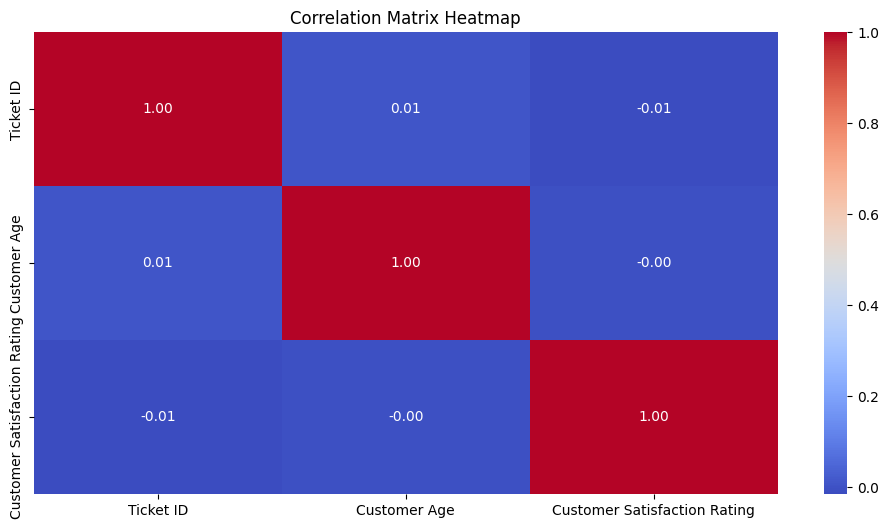

In [17]:
# Correlation matrix heatmap

plt.figure(figsize=(12, 6))
sns.heatmap(data[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

### ***Categorical Features***

/tmp/ipykernel_6372/276738276.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette='magma', order=data[col].value_counts().index)


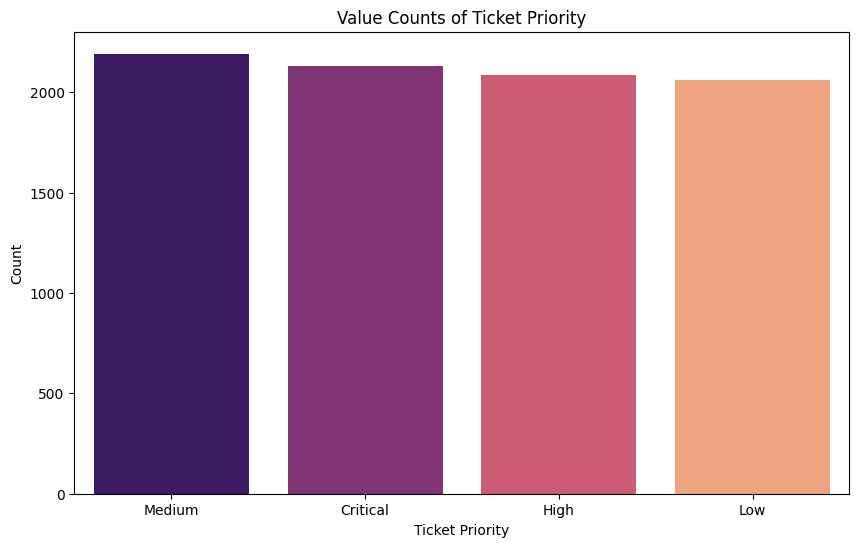

/tmp/ipykernel_6372/276738276.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette='magma', order=data[col].value_counts().index)


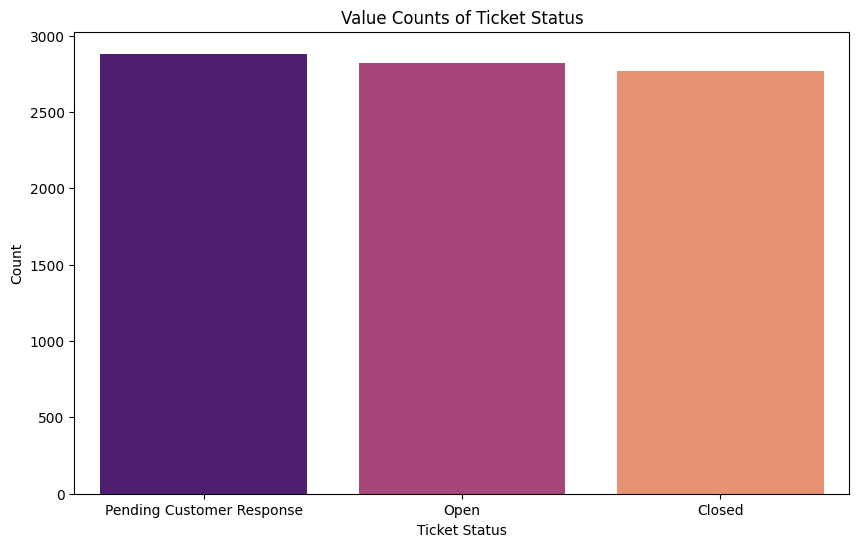

/tmp/ipykernel_6372/276738276.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette='magma', order=data[col].value_counts().index)


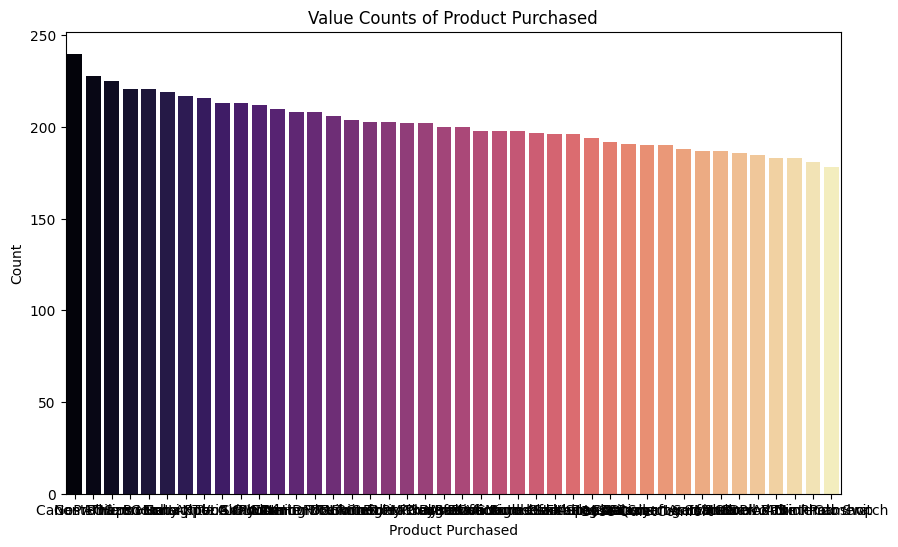

In [18]:
# Value counts (bar chart)

categorical_cols = ['Ticket Priority', 'Ticket Status', 'Product Purchased']

for col in categorical_cols:
    if col in data.columns:
        plt.figure(figsize=(10, 6))
        sns.countplot(data=data, x=col, palette='magma', order=data[col].value_counts().index)
        plt.title(f'Value Counts of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.show()

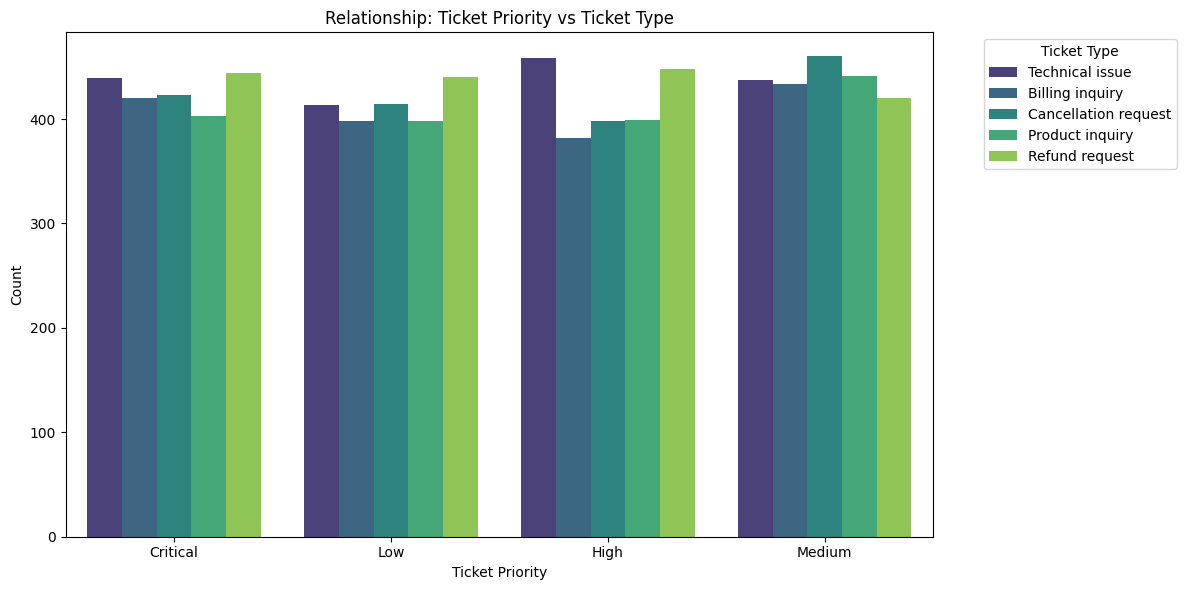

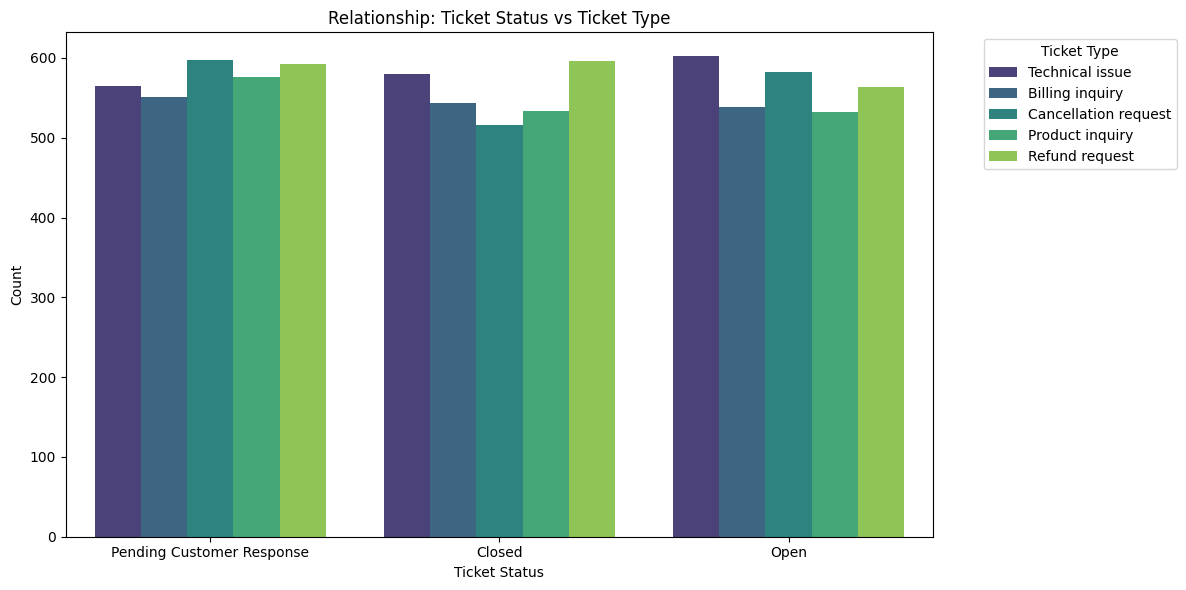

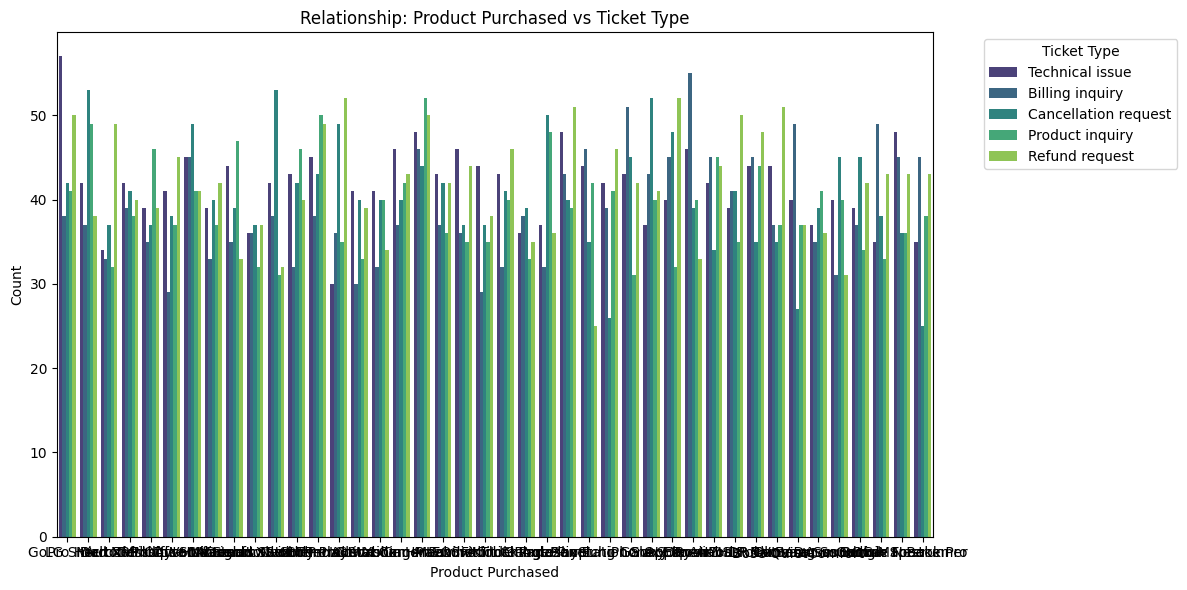

In [19]:
# Category vs target relationship (grouped bar chart)

for col in categorical_cols:
    if col in data.columns:
        plt.figure(figsize=(12, 6))
        sns.countplot(data=data, x=col, hue='Ticket Type', palette='viridis')
        plt.title(f'Relationship: {col} vs Ticket Type')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.legend(title='Ticket Type', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

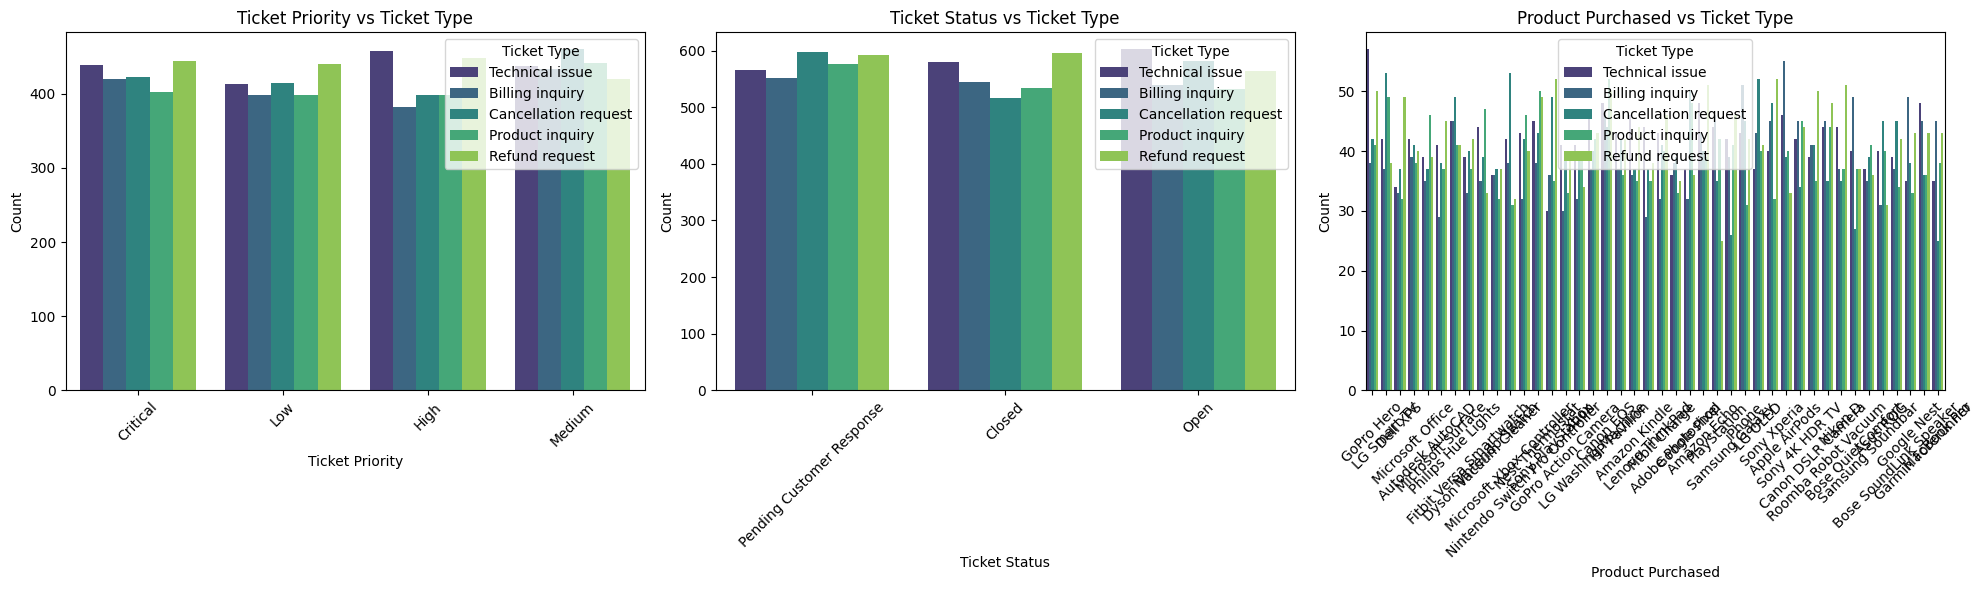

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=len(categorical_cols), figsize=(20, 6))

for i, col in enumerate(categorical_cols):
    if col in data.columns:
        sns.countplot(data=data, x=col, hue='Ticket Type', palette='viridis', ax=axes[i])
        axes[i].set_title(f'{col} vs Ticket Type')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

### ***Text Data***

In [21]:
data

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaN,NaN,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaN,NaN,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0


In [23]:
# Preparing the input

data['input'] = data['Ticket Subject'] + ' ' + data['Ticket Description']
data['input']

,input
0,Product setup I'm having an issue with the {pr...
1,Peripheral compatibility I'm having an issue w...
2,Network problem I'm facing a problem with my {...
3,Account access I'm having an issue with the {p...
4,Data loss I'm having an issue with the {produc...
...,...
8464,Installation support My {product_purchased} is...
8465,Refund request I'm having an issue with the {p...
8466,Account access I'm having an issue with the {p...
8467,Payment issue I'm having an issue with the {pr...


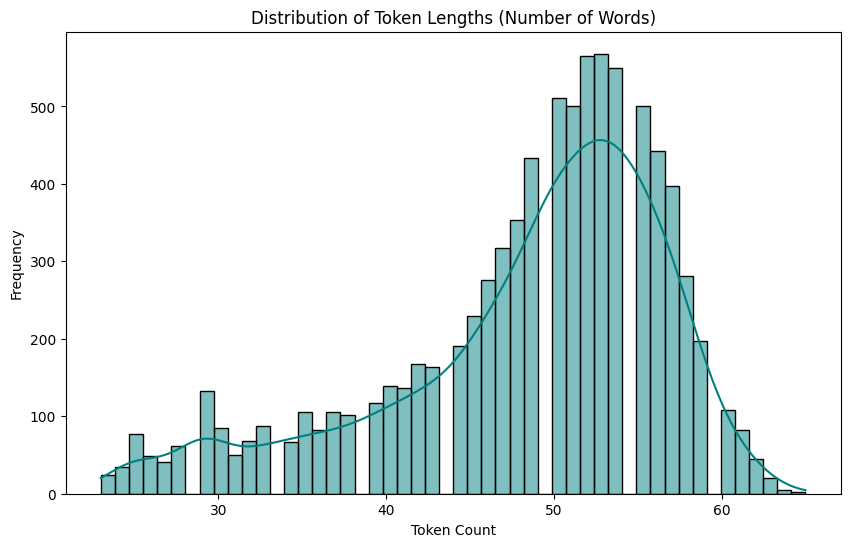

In [24]:
# Token length distribution

data['token_length'] = data['input'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(data['token_length'], bins=50, kde=True, color='teal')
plt.title('Distribution of Token Lengths (Number of Words)')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.show()

In [25]:
!pip install nltk

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


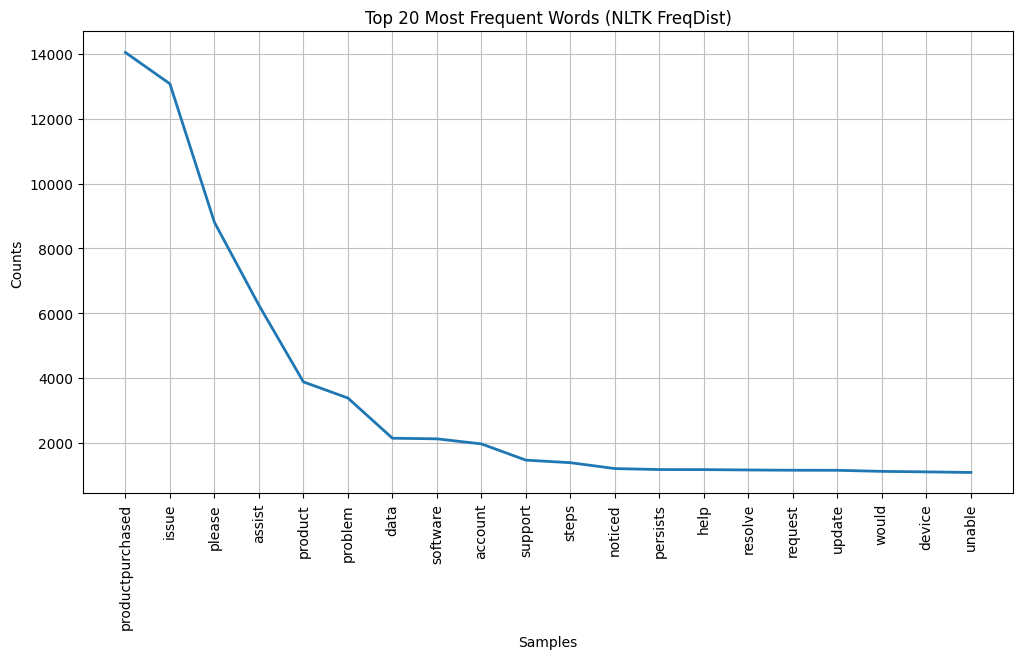

In [27]:
# Most frequent words (top N)

import nltk
from nltk.probability import FreqDist
from nltk.corpus import stopwords
import re

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def get_clean_words(text_series):
    words = " ".join(text_series.astype(str)).lower().split()
    return [re.sub(r'[^a-z]', '', w) for w in words if w not in stop_words and len(re.sub(r'[^a-z]', '', w)) > 2]

all_clean_words = get_clean_words(data['input'])
fdist = FreqDist(all_clean_words)

plt.figure(figsize=(12, 6))
fdist.plot(20, title='Top 20 Most Frequent Words (NLTK FreqDist)')
plt.show()

In [28]:
!pip install wordcloud

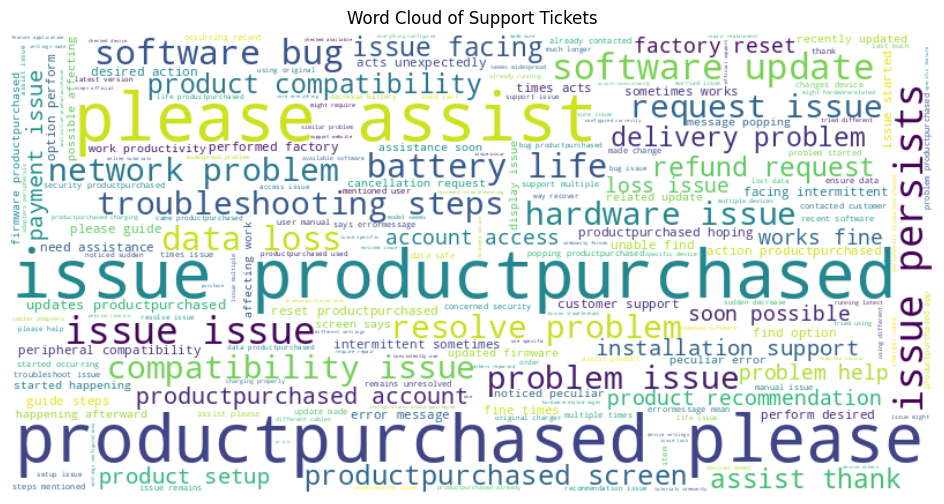

In [30]:
# Word cloud (optional)

from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(all_clean_words))

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Support Tickets')
plt.show()

/tmp/ipykernel_6372/1604180720.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(labels), palette='magma')


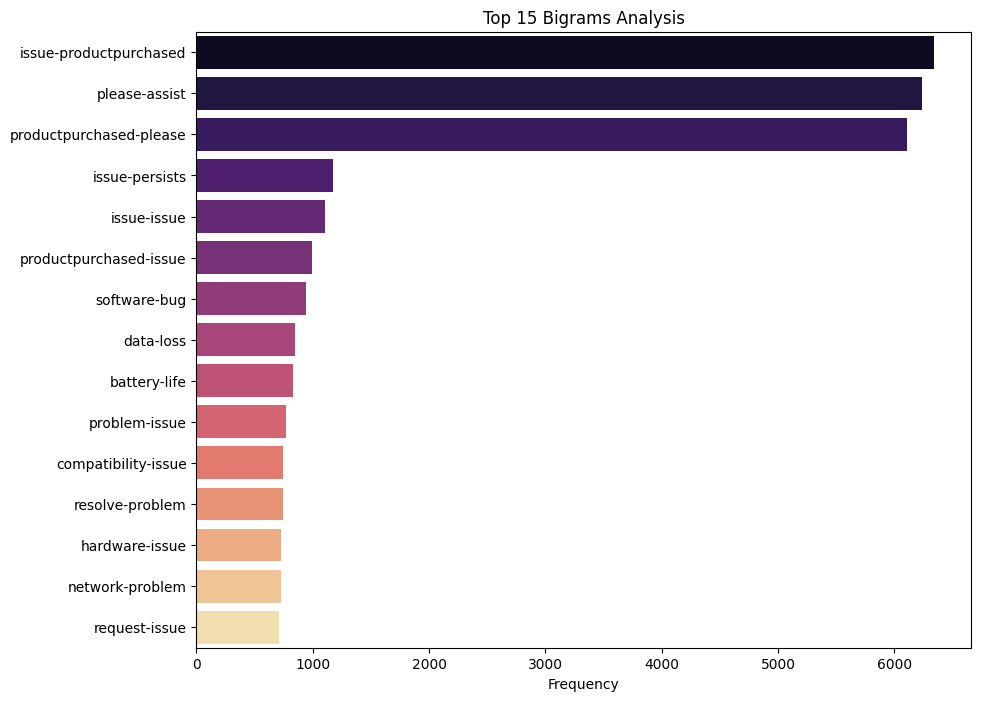

In [31]:
# N-grams analysis

from nltk.util import ngrams
from collections import Counter

bigrams = list(ngrams(all_clean_words, 2))
bigram_counts = Counter(bigrams)

top_bigrams = bigram_counts.most_common(15)
labels, counts = zip(*[("-".join(bg), c) for bg, c in top_bigrams])

plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(labels), palette='magma')
plt.title('Top 15 Bigrams Analysis')
plt.xlabel('Frequency')
plt.show()

## **4. Data Quality Checks **

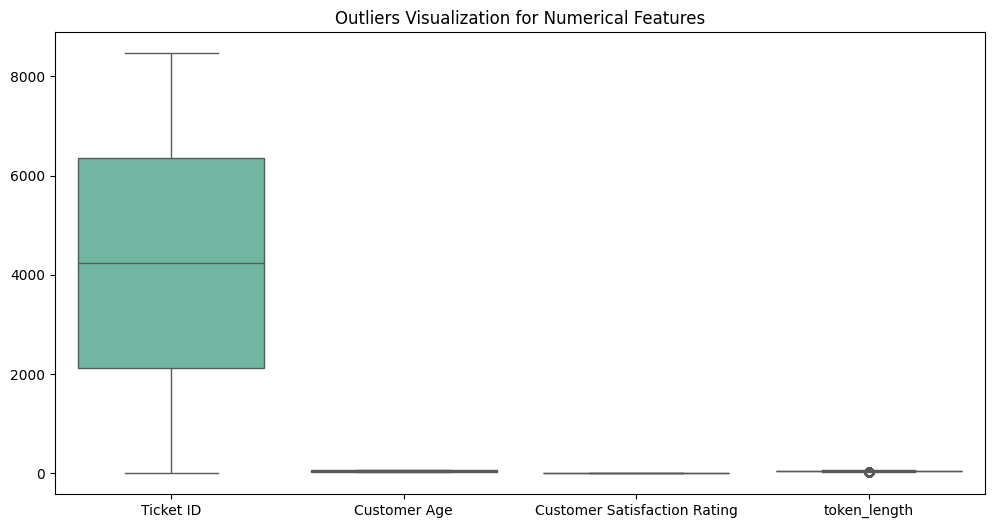

In [32]:
# Outliers visualization

numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns

if len(numerical_cols) > 0:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=data[numerical_cols], palette='Set2')
    plt.title('Outliers Visualization for Numerical Features')
    plt.show()

Skewness Detection Results:
Ticket ID                       0.000000
Customer Age                   -0.017172
Customer Satisfaction Rating    0.008370
token_length                   -1.029582
dtype: float64


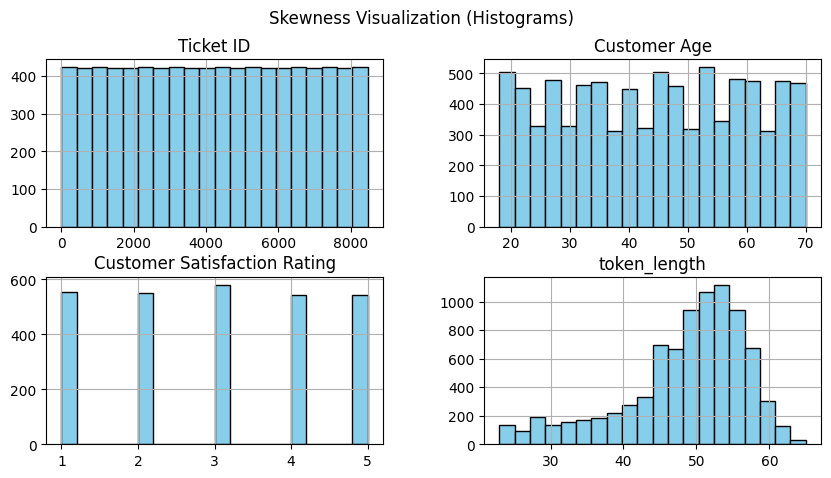

In [33]:
# Skewness detection

if len(numerical_cols) > 0:
    print("Skewness Detection Results:")
    skew_values = data[numerical_cols].skew()
    print(skew_values)

    data[numerical_cols].hist(bins=20, figsize=(10, 5), color='skyblue', edgecolor='black')
    plt.suptitle('Skewness Visualization (Histograms)')
    plt.show()

In [34]:
# Feature scaling need

if len(numerical_cols) > 0:
    scaling_check = data[numerical_cols].describe().loc[['min', 'max', 'mean']]
    print("Feature Scaling Needs Analysis:")
    print(scaling_check)

Feature Scaling Needs Analysis:
      Ticket ID  Customer Age  Customer Satisfaction Rating  token_length
min         1.0     18.000000                      1.000000     23.000000
max      8469.0     70.000000                      5.000000     65.000000
mean     4235.0     44.026804                      2.991333     48.467352


In [36]:
# Noise / anomalies inspection

print("Noise Inspection (Sample Text):")
print(data['input'].sample(5).values)

categorical_cols = data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if col != 'text_input':
        print(f"\nUnique values in {col}: {data[col].nunique()}")

Noise Inspection (Sample Text):
['Software bug I\'m having an issue with the {product_purchased}. Please assist.\n\n#$USER["ProductName"] = "Etsy" $USE_SERVICE(false);\n\nThen we want to connect to Etsy and provide I\'ve recently updated the firmware of my {product_purchased}, and the issue started happening afterward. Could it be related to the update?'
 'Network problem I\'m having an issue with the {product_purchased}. Please assist.\n\nMy order arrived this day, and the quality of the quality of my "purchased" orders were awesome. I would have expected higher quality products from I rely heavily on my {product_purchased} for my daily tasks, and this issue is hindering my productivity.'
 "Cancellation request I've forgotten my password for my {product_purchased} account, and the password reset option is not working. How can I recover my account? I know I didn't log in to this game then or when, and I haven't I've checked the device settings and made sure that everything is configure

## **5. Pre-processing**

In [37]:
# Drop unimportant columns

cols_to_drop = [
    'Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
    'Customer Gender', 'Customer Satisfaction Rating', 'Time to Resolution',
    'Resolution', 'First Response Time']

data.drop(columns=cols_to_drop, axis=1, inplace=True)

print("Columns are deleted")
print(data.columns.tolist())

Columns are deleted
['Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Ticket Priority', 'Ticket Channel', 'input', 'token_length']


In [41]:
# Prepare Liberaries

import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [42]:
# Function to Preprocessing

def preprocess_text(text):
    text = str(text).lower()

    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)

    tokens = word_tokenize(text)

    clean_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return " ".join(clean_tokens)

In [43]:
# Apply the function on the data

data['final_processed_text'] = data['input'].apply(preprocess_text)

print("Before Pre-processing:")
print(data['input'].iloc[0])

print("\nAfter Pre-processing:")
print(data['final_processed_text'].iloc[0])

Before Pre-processing:
Product setup I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.

After Pre-processing:
product setup im issue productpurchased please assist billing zip code appreciate requested website address please double check email address ive tried troubleshooting step mentioned user manual issue persists


## **6. Representation **

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)

X_train, X_test, y_train, y_test = train_test_split(data['final_processed_text'], data['Ticket Type'], test_size=0.2, random_state=42,
    stratify=data['Ticket Type'])

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print(f"Train Shape: {X_train_tfidf.shape}")
print(f"Test Shape: {X_test_tfidf.shape}")


Train Shape: (6775, 5000)
Test Shape: (1694, 5000)


## **7. ML Models**